# Empirical Closed-form Model (matches Voc,Isc,Vmp,Imp)

$I(V) = I_{sc} * [1-C_{1}e^{\frac{V}{C_{2}•V_{Oc}}}]$

$C₂ = (Vmp/Voc − 1) / ln(1 − Imp/Isc)$

$C₁ = (1 − I{mp}/I{sc}) · e^{(−V{mp} / (C₂·V{oc}))}$

This is the standard closed-form approximation in PV engineering. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy.optimize import brentq

In [2]:
# Inputs
grid_resolution = 4096 # Tied to 12-bit ADC of ESP32 and similar models
# Assumed inputs
Voc = 21.5
Isc = 3.0
Vmp = 17.5
Imp = 2.7

V_grid = np.linspace(0,Voc,grid_resolution) # Building up the voltage grid

def I_pv(V,Isc,C1,C2,Voc):
    return Isc*(1-C1*(np.exp(V/(C2*Voc))-1)) # Running through equation

def generate_curve(Voc,Isc,Vmp,Imp,V_grid):
    C2 = (Vmp/Voc-1)/math.log(1-Imp/Isc)
    C1 = (1-Imp/Isc)*math.exp(-Vmp/(C2*Voc))

    I_grid = I_pv(V_grid,Isc,C1,C2,Voc)
    P = V_grid*I_grid

    # Ground-Truth MPP
    idx = np.argmax(P)
    V_mpp = V_grid[idx]
    P_mpp = P[idx]
    return I_grid,V_grid,P,V_mpp,P_mpp,C1,C2

I_grid,V_grid,P_grid,V_mpp,P_mpp,C1,C2 = generate_curve(Voc,Isc,Vmp,Imp,V_grid)
# Tests
print(I_grid[0])   # should be ≈ 3.0 (Isc)
print(I_grid[-1])  # should be ≈ 0 (at V = Voc)
print(V_mpp)  # should land close to 17.5 (Vmp)



3.0
1.2650895100163595e-05
17.33650793650794


Text(0.5, 1.0, 'Empirical Current-Voltage Curve')

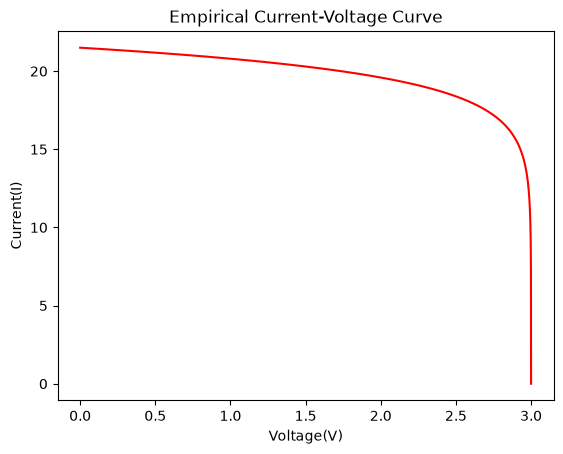

In [3]:
plt.plot(I_grid,V_grid,linestyle='solid',color='r')
plt.xlabel('Voltage(V)')
plt.ylabel('Current(I)')
plt.title("Empirical Current-Voltage Curve")

# Environmental Variation

Standard first order relations are:

$I_{sc}(G) = I_{sc,ref}*(G/G_{ref})$ 
Short circuit current scales linearly with irradiance

$V_{oc}(T) = V_{oc,ref} + \beta*(T-T_{ref})$
Open circuit voltage has a negtaive temperature coefficient $\beta$

In [4]:
def environmentalvariation(Voc,Isc,Vmp,Imp,V_grid,G,T,G_ref,T_ref,beta):
    IscG = Isc*(G/G_ref)
    VocT = Voc + beta*(T-T_ref)
    ImpG = Imp*(G/G_ref)
    VmpT = Vmp + beta*(T-T_ref)

    I_grid,V_grid,P_grid,V_mpp,P_mpp,C1,C2 = generate_curve(VocT,IscG,VmpT,ImpG,V_grid)

    return I_grid,V_grid,P_grid,V_mpp,P_mpp,C1,C2

# Buck Converter Simulation

In [5]:
def buck_converter(R_load,D):
    R_in = (1/D**2)*R_load
    return R_in
R_load = 2.7 # Assumed from using R_load = R_mpp * D**2
D = 0.5
R_in = buck_converter(R_load,D)

def res(V,R_in,Isc,C1,C2,Voc):
    return I_pv(V,Isc,C1,C2,Voc) - V/R_in


# MPPT Algorithm Design

## IncCond

### Residual Function Solving

In [6]:
def brentqsolve(R_in,Voc,Isc,C1,C2):
    V_solution = brentq(res,a=1e-6,b=Voc,args = (R_in,Isc,C1,C2,Voc))
    I_solution = I_pv(V_solution,Isc,C1,C2,Voc)
    return V_solution,I_solution

### Main Algorithm

In [7]:
N = 100 # Iterations
D = np.zeros(N)
D[0] = 0.5
V_traj = np.zeros(N)
I_traj = np.zeros(N)


def incCond(N,D,Isc,C1,C2,deltaD=5e-5,epsilon=1e-2,tolerance=1e-6):
    V_traj = np.zeros(N)
    I_traj = np.zeros(N)
    for i in range(N):
        R_in = buck_converter(R_load,D[i])
        V_traj[i],I_traj[i] = brentqsolve(R_in,Voc,Isc,C1,C2)
        if i == 0 and i+1 < N:
            D[i+1] = D[i] + deltaD  # forced pertubation
        elif i+1<N:
            D[i+1] = D[i]
        if i>0 and i+1<N:
            deltaV = V_traj[i] - V_traj[i-1]
            deltaI = I_traj[i] - I_traj[i-1]
            if np.abs(deltaV)<tolerance:
                if np.abs(deltaI)<tolerance:
                    pass
                elif deltaI >0:
                    D[i+1] +=deltaD
                else:
                    D[i+1] -= deltaD
            else:
                dI_dV = deltaI/deltaV
                target = -I_traj[i]/V_traj[i]
                if np.abs(dI_dV - target)<epsilon:
                    pass
                elif dI_dV<target:
                    D[i+1] += deltaD
                else:
                    D[i+1] -= deltaD
    return D, V_traj, I_traj

### How IncCond varies with number of iterations

For iterations:  100  Saturation voltage: 19.803611354800296
For iterations: 1000  Saturation voltage: 19.287564556546656
For iterations: 1500  Saturation voltage: 18.928160662414584
For iterations: 3000  Saturation voltage: 17.425757713833402
For iterations: 3500  Saturation voltage: 17.425757713833402
For iterations: 5000  Saturation voltage: 17.425757713833402


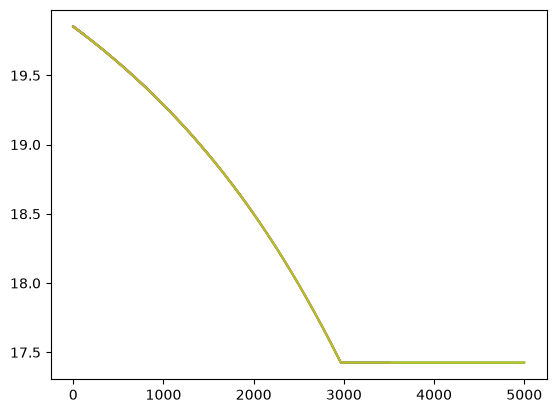

In [8]:
D = np.zeros(N)
D[0] = 0.5
_,V_iC_100,_ = incCond(100,D,Isc,C1,C2)
D = np.zeros(2000)
D[0] = 0.5
_,V_iC_200,_ = incCond(2000,D,Isc,C1,C2)
D = np.zeros(5000)
D[0] = 0.5
_,V_iC_300,_ = incCond(5000,D,Isc,C1,C2)

plt.plot(V_iC_100)
plt.plot(V_iC_200)
plt.plot(V_iC_300)

for i in [100,1000,1500,3000,3500,5000]:
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_ = incCond(i,D,Isc,C1,C2)
    plt.plot(V_current)
    
    print(f"For iterations: {i:4}  Saturation voltage: {V_current[-1]}")


### Ideal number of iterations given constant deltaD

In [9]:
# Ideal convergence criteria(in terms of iterations given deltaD)
i = 0
tolerance_check = 0.02 # %
while 5>0:
    i+=100
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_ = incCond(i,D,Isc,C1,C2)
    
    if np.abs(V_current[-1]-V_mpp)<tolerance_check*V_mpp:
        converged_itr = i
        print("Converged iteration: " + str(i))
        break
    



Converged iteration: 2800


### Point of convergence

In [10]:

D[0] = 0.5
_,V_converged,_ = incCond(converged_itr,D,Isc,C1,C2)
tolerance_check = 0.02  # 2%
converged_idx = np.argmax(np.abs(V_converged- V_mpp) < tolerance_check * V_mpp)
print(converged_idx)



2762


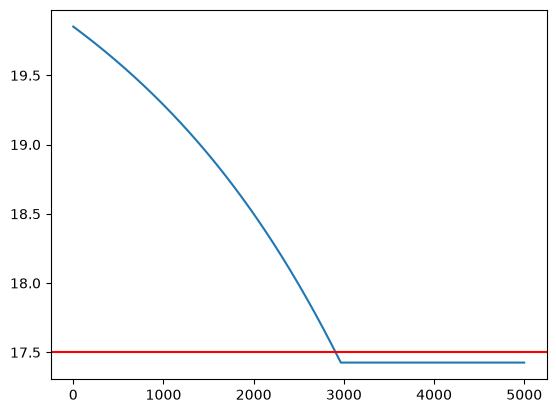

In [11]:
D = np.zeros(5000)
D[0] = 0.5
_,V_5000,_ = incCond(5000,D,Isc,C1,C2)
plt.plot(V_5000)
plt.axhline(Vmp, color = 'r', label = 'True MPP')


### Measuring Oscillation with respect to step-size

In [12]:
i = 0
for i in [5e-5,4e-5,2e-5,9e-4,5e-4,1e-4,1e-3,1e-2]:
    D = np.zeros(5000)
    D[0] = 0.5
    _,V,_ = incCond(5000,D,Isc,C1,C2,deltaD = i)
    StandardDeviation = round(np.std(V[:-50])*100)/100
    ConvergingPoint = round(V[-1]*1000)/1000
    print(f"Given deltaD: {i:6} Standard Deviation: {StandardDeviation:4} Converging point: {ConvergingPoint}")





Given deltaD:  5e-05 Standard Deviation: 0.88 Converging point: 17.426
Given deltaD:  4e-05 Standard Deviation: 0.86 Converging point: 17.426
Given deltaD:  2e-05 Standard Deviation: 0.38 Converging point: 18.5
Given deltaD: 0.0009 Standard Deviation: 0.29 Converging point: 17.397
Given deltaD: 0.0005 Standard Deviation: 0.38 Converging point: 17.421
Given deltaD: 0.0001 Standard Deviation: 0.75 Converging point: 17.426
Given deltaD:  0.001 Standard Deviation: 0.27 Converging point: 17.407
Given deltaD:   0.01 Standard Deviation: 0.09 Converging point: 17.381


## IncCond in response to Environmental Variation

In [13]:
# Inputs
grid_resolution = 4096 # Tied to 12-bit ADC of ESP32 and similar models
# Assumed inputs
Voc = 21.5
Isc = 3.0
Vmp = 17.5
Imp = 2.7

V_grid = np.linspace(0,Voc,grid_resolution)
# Standard Test conditions(STC) - IEC wide convention
G_ref = 1000 #W/m^2
T_ref = 298.15 # K

beta = -0.075 # A standard midrange figure for Crystalline Sillicon

This is how the simulation will go:
- Baseline test: G = 1000, T = 25 
- Partial cloud: G = 1000-> 400, T = 25
- Hot day: G =  1000, T = 60
- Cold clear: G = 1000, T = 0
- Overcast: G = 300, T = 25
- Worst: G = 200, T = 70
- Ramp: 1000-> 200(slowly), T = 25

Metrics to grade:
1. V(t) and I(t) traces: the whole time series(oscillation, overshoot, direction reversals)
2. P(t) = V(t)*I(t) 
3. True P_max(G,T): actual peak of P-V, for the current(G,T)
4. Tracking efficiency $\eta = \frac{\int P(t) dt}{\int P_{max} (G(t),T(t))dt}$
5. Settling/convergence time - How long after a G-step, until V(t) stabilizes within some % of Vmpp.
6. Overshoot/false-tracking behavior during step tests



In [14]:
# Baseline Test


def incCond_env(N,D,G_profile,T_profile,Voc_ref,Isc_ref,Vmp_ref,Imp_ref,G_ref,T_ref,beta,R_load, deltaD = 5e-5, epsilon = 1e-2, tolerance = 1e-6):
    V_traj = np.zeros(N)
    I_traj = np.zeros(N)
    Pmax_traj = np.zeros(N) # Used for tracking efficiency later w.r.t "time"
    
    for i in range(N):
        G,T = G_profile[i],T_profile[i]
        V_grid = np.linspace(0,Voc_ref,500)
        _,_,_,V_mpp,P_mpp,C1,C2 = environmentalvariation(Voc,Isc,Vmp,Imp,V_grid,G,T,G_ref,T_ref,beta)
        Pmax_traj[i] = P_mpp

        IscG = Isc_ref*(G/G_ref)
        VocT = Voc_ref + beta*(T-T_ref)
        
        R_in = buck_converter(R_load, D[i])
        V_traj[i], I_traj[i] = brentqsolve(R_in,VocT,IscG,C1,C2)

        if i == 0 and i+1 < N:
            D[i+1] = D[i] + deltaD
        elif i+1 < N:
            D[i+1] = D[i]
        if i > 0 and i+1 < N:
            deltaV = V_traj[i] - V_traj[i-1]
            deltaI = I_traj[i] - I_traj[i-1]
            if np.abs(deltaV) < tolerance:
                if np.abs(deltaI) < tolerance:
                    pass
                elif deltaI > 0:
                    D[i+1] += deltaD
                else:
                    D[i+1] -= deltaD
            else:
                dI_dV = deltaI/deltaV
                target = -I_traj[i]/V_traj[i]
                if np.abs(dI_dV - target) < epsilon:
                    pass
                elif dI_dV < target:
                    D[i+1] += deltaD
                else:
                    D[i+1] -= deltaD

    return D, V_traj, I_traj, Pmax_traj        

### Test Code(using deltaD = 1e-3)

In [15]:
def stepfunc(N,idx,before,after): # To create step functions
    p = np.full(N,before)
    p[idx:] = after
    return p

def rampfunc(N,idx,start,end): # To create the ramping func
    return np.concatenate([np.full(idx,start),np.linspace(start,end,N-idx)])

def settling_time(V_traj,step_idx,V_target,tol_pct = 0.02):
    band = tol_pct*V_target
    valuesinside = np.abs(V_traj-V_target)<band
    for i in range(step_idx,len(V_traj)):
        if np.all(valuesinside[i:]):
            return i - step_idx
    return None # If never settle
    
def overshoot_metrics(V_traj,step_idx,V_before,V_target,window=50):
    post = V_traj[step_idx:step_idx+window] # last 50 iterations(after environmental step)

    if V_target>V_before:
        overshoot = np.max(post)-V_target
    else:
        overshoot = V_target - np.min(post)
    overshoot_pct = 100*overshoot/V_target

    direction_needed = np.sign(V_target-V_before)
    early_moves = np.diff(V_traj[step_idx:step_idx+10])
    wrong_direction_steps = int(np.sum(np.sign(early_moves) != direction_needed))
    return overshoot_pct,wrong_direction_steps

N = 5000
T25, T0, T60, T70 = 298.15,273.15,333.15,343.15 # Temperatures required for tests
step_idx = N//2

testscenarios = {
    "baseline":(np.full(N,1000.0),T25),
    "partial_cloud":(stepfunc(N,step_idx,1000,400),T25),
    "hot_day":(np.full(N,1000.0),T60),
    "cold_clear":(np.full(N,1000.0),T0),
    "overcast":(np.full(N,300.0),T25),
    "worst_case":(np.full(N,200.0),T70),
    "ramp":(rampfunc(N,step_idx,1000,200),T25),
}
results = {}
for name, (G_profile, T_val) in testscenarios.items():
    T_profile = np.full(N,T_val)
    D = np.zeros(N)
    D[0] = 0.5
    D,V_traj,I_traj, Pmax_traj = incCond_env(N,D,G_profile,T_profile,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD = 1e-3)
    P_traj = V_traj*I_traj
    
    # Efficiency evaluation
    eta = np.trapezoid(P_traj)/np.trapezoid(Pmax_traj)

    # Ground-truth V_mpp for the final condition(what it SHOULD settle to)
    _,_,_,V_mpp_final,_,_,_ = environmentalvariation(Voc,Isc,Vmp,Imp,V_grid,G_profile[-1],T_profile[-1],G_ref,T_ref,beta)
    
    if name in ("partial_cloud","ramp"):
        t_settle = settling_time(V_traj,step_idx,V_mpp_final)
        V_before = V_traj[step_idx-1]
        overshoot_pct,wrong_steps = overshoot_metrics(V_traj, step_idx, V_before, V_mpp_final)
    else:
        t_settle = settling_time(V_traj,0,V_mpp_final)
        overshoot_pct,wrong_steps = None, None # Not applicable for these scenarios.

    results[name] = dict(V=V_traj, I=I_traj, P=P_traj, Pmax = Pmax_traj, eta = eta,settle = t_settle, overshoot = overshoot_pct, wrong_steps = wrong_steps)
    print(f"{name:15s} Efficiency={round(eta*100):3}% Settle = {t_settle}  "
        f"Overshoot = {overshoot_pct if overshoot_pct is None else f'{round(overshoot_pct):3}%'} "
        f"Wrong Direction steps = {wrong_steps}")
    

baseline        Efficiency=100% Settle = 139  Overshoot = None Wrong Direction steps = None
partial_cloud   Efficiency= 99% Settle = 229  Overshoot =  56% Wrong Direction steps = 9
hot_day         Efficiency=100% Settle = 183  Overshoot = None Wrong Direction steps = None
cold_clear      Efficiency=100% Settle = 111  Overshoot = None Wrong Direction steps = None
overcast        Efficiency= 99% Settle = 139  Overshoot = None Wrong Direction steps = None
worst_case      Efficiency= 99% Settle = None  Overshoot = None Wrong Direction steps = None
ramp            Efficiency=100% Settle = None  Overshoot =   0% Wrong Direction steps = 4


In [16]:
D=np.zeros(5000); D[0]=0.5
_,V,I, = incCond(5000,D,Isc,C1,C2,deltaD=5e-5)
dV=np.diff(V); dI=np.diff(I)

mask = dV != 0   # exclude points where incCond is holding still
gap = np.abs(dI[mask]/dV[mask] - (-I[1:][mask]/V[1:][mask]))
print('typical gap near convergence:', np.median(gap[-500:]))
print('fraction of last 500 steps that are LOCKED (dV==0):', np.mean(~mask[-500:]))

typical gap near convergence: 0.048400400428629614
fraction of last 500 steps that are LOCKED (dV==0): 1.0


# Perturb and Observe(P&O)

It works on the basis of gradient ascent, essentially perturb the operating point, and observe whether the power went up or down, then decide the next move from that observation alone.

## The update rule
Given at each step, you have a duty cycle $D_{k}$, producing a power $P_{k}$, the algorithm computes:
$$\Delta P_{k} = P_{k} - P_{k-1}$$
and:
$$D_{k+1} = D_{k} + sign(k)* \Delta D$$
Where sign(k) [direction] updates as:
$sign(k)= \begin{cases}
sign(k-1) & \text{if } \Delta P_{k}>0 \\
-sign(k-1) & \text{if } \Delta P_{k}<0 
\end{cases}$

It never actually cvonverges however, since at the peak it will direction flip every time. It's guaranteed to be $\pm \Delta D$ 

## Main Algorithm 

In [17]:
def PandO(N,D,Isc,C1,C2,Voc,deltaD = 5e-5):
    V_traj = np.zeros(N)
    I_traj = np.zeros(N)
    P_traj = np.zeros(N)
    direction=1 # Initial direction, can be + or minus 1.

    for i in range(N):
        R_in = buck_converter(R_load, D[i])
        V_traj[i], I_traj[i] = brentqsolve(R_in, Voc,Isc, C1, C2)
        P_traj[i] = V_traj[i]*I_traj[i]

        if i == 0:
            if i+1 < N:
                D[i+1] = D[i] + deltaD*direction
            continue
        dP = P_traj[i] - P_traj[i-1]

        if dP<0:
            direction *= -1
        if i+1<N:
            D[i+1] = D[i] + deltaD*direction

    return D, V_traj, I_traj, P_traj



## How P&O changes with iterations

For iterations:  100  Saturation voltage: 19.803611354800296
For iterations: 1000  Saturation voltage: 19.287564556546656
For iterations: 1500  Saturation voltage: 18.928160662414584
For iterations: 3000  Saturation voltage: 17.38253854534433
For iterations: 3500  Saturation voltage: 17.337544555270625
For iterations: 5000  Saturation voltage: 17.337544555270625


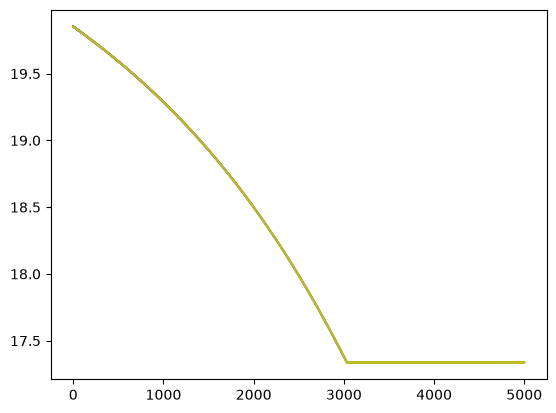

In [18]:
D = np.zeros(N)
D[0] = 0.5
_,V_iC_100,_,_ = PandO(100,D,Isc,C1,C2,Voc)
D = np.zeros(2000)
D[0] = 0.5
_,V_iC_200,_,_ = PandO(2000,D,Isc,C1,C2,Voc)
D = np.zeros(5000)
D[0] = 0.5
_,V_iC_300,_,_ = PandO(5000,D,Isc,C1,C2,Voc)

plt.plot(V_iC_100)
plt.plot(V_iC_200)
plt.plot(V_iC_300)

for i in [100,1000,1500,3000,3500,5000]:
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_,_ = PandO(i,D,Isc,C1,C2,Voc)
    plt.plot(V_current)
    
    print(f"For iterations: {i:4}  Saturation voltage: {V_current[-1]}")


## Ideal number of iterations given constant D

In [19]:
# Ideal convergence criteria(in terms of iterations given deltaD)
i = 0
tolerance_check = 0.02 # %
while 5>0:
    i+=100
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_,_ = PandO(i,D,Isc,C1,C2,Voc)
    
    if np.abs(V_current[-1]-V_mpp)<tolerance_check*V_mpp:
        converged_itr = i
        print("Converged iteration: " + str(i))
        break
    



Converged iteration: 2800


## Measuring Oscillaton w.r.t Step size

In [20]:
i = 0
for i in [5e-5,4e-5,2e-5,9e-4,5e-4,1e-4,1e-3,1e-2]:
    D = np.zeros(5000)
    D[0] = 0.5
    _,V,_,_ = PandO(5000,D,Isc,C1,C2,Voc,deltaD = i)
    StandardDeviation = round(np.std(V[:-50])*100)/100
    ConvergingPoint = round(V[-1]*1000)/1000
    print(f"Given deltaD: {i:6} Standard Deviation: {StandardDeviation:4} Converging point: {ConvergingPoint}")





Given deltaD:  5e-05 Standard Deviation: 0.91 Converging point: 17.338
Given deltaD:  4e-05 Standard Deviation: 0.88 Converging point: 17.338
Given deltaD:  2e-05 Standard Deviation: 0.38 Converging point: 18.5
Given deltaD: 0.0009 Standard Deviation:  0.3 Converging point: 17.373
Given deltaD: 0.0005 Standard Deviation: 0.39 Converging point: 17.342
Given deltaD: 0.0001 Standard Deviation: 0.79 Converging point: 17.342
Given deltaD:  0.001 Standard Deviation: 0.29 Converging point: 17.355
Given deltaD:   0.01 Standard Deviation: 0.21 Converging point: 17.381


## How P&O responds to Environmental Variation

In [21]:
# Inputs
grid_resolution = 4096 # Tied to 12-bit ADC of ESP32 and similar models
# Assumed inputs
Voc = 21.5
Isc = 3.0
Vmp = 17.5
Imp = 2.7

V_grid = np.linspace(0,Voc,grid_resolution)
# Standard Test conditions(STC) - IEC wide convention
G_ref = 1000 #W/m^2
T_ref = 298.15 # K

beta = -0.075 # A standard midrange figure for Crystalline Sillicon

In [22]:
def PandO_env(N, D, G_profile, T_profile, Voc_ref, Isc_ref, Vmp_ref, Imp_ref,
              G_ref, T_ref, beta, R_load, deltaD=5e-5):
    V_traj = np.zeros(N)
    I_traj = np.zeros(N)
    P_traj = np.zeros(N)
    Pmax_traj = np.zeros(N)
    direction = 1

    for i in range(N):
        G,T = G_profile[i],T_profile[i]
        V_grid=np.linspace(0, Voc_ref, 500)
        _,_,_,_,P_mpp,C1,C2=environmentalvariation(Voc_ref,Isc_ref,Vmp_ref,Imp_ref,V_grid,G,T,G_ref,T_ref,beta)
        Pmax_traj[i] = P_mpp

        IscG = Isc_ref*(G/G_ref)
        VocT = Voc_ref+beta*(T - T_ref)

        R_in = buck_converter(R_load, D[i])
        V_traj[i],I_traj[i] = brentqsolve(R_in,VocT,IscG,C1,C2)
        P_traj[i] = V_traj[i]*I_traj[i]

        if i == 0:
            if i+1 < N:
                D[i+1] = D[i]+deltaD*direction
            continue

        dP = P_traj[i]-P_traj[i-1]
        if dP < 0:
            direction *= -1

        if i+1 < N:
            D[i+1] = D[i]+deltaD*direction

    return D, V_traj,I_traj,Pmax_traj

In [23]:
N = 5000
T25, T0, T60, T70 = 298.15,273.15,333.15,343.15 # Temperatures required for tests
step_idx = N//2

testscenarios = {
    "baseline":(np.full(N,1000.0),T25),
    "partial_cloud":(stepfunc(N,step_idx,1000,400),T25),
    "hot_day":(np.full(N,1000.0),T60),
    "cold_clear":(np.full(N,1000.0),T0),
    "overcast":(np.full(N,300.0),T25),
    "worst_case":(np.full(N,200.0),T70),
    "ramp":(rampfunc(N,step_idx,1000,200),T25),
}
results = {}
for name, (G_profile, T_val) in testscenarios.items():
    T_profile = np.full(N,T_val)
    D = np.zeros(N)
    D[0] = 0.5
    D,V_traj,I_traj, Pmax_traj = PandO_env(N,D,G_profile,T_profile,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD = 5e-5)
    P_traj = V_traj*I_traj
    
    # Efficiency evaluation
    eta = np.trapezoid(P_traj)/np.trapezoid(Pmax_traj)

    # Ground-truth V_mpp for the final condition(what it SHOULD settle to)
    _,_,_,V_mpp_final,_,_,_ = environmentalvariation(Voc,Isc,Vmp,Imp,V_grid,G_profile[-1],T_profile[-1],G_ref,T_ref,beta)
    
    if name in ("partial_cloud","ramp"):
        t_settle = settling_time(V_traj,step_idx,V_mpp_final)
        V_before = V_traj[step_idx-1]
        overshoot_pct,wrong_steps = overshoot_metrics(V_traj, step_idx, V_before, V_mpp_final)
    else:
        t_settle = settling_time(V_traj,0,V_mpp_final)
        overshoot_pct,wrong_steps = None, None # Not applicable for these scenarios.

    results[name] = dict(V=V_traj, I=I_traj, P=P_traj, Pmax = Pmax_traj, eta = eta,settle = t_settle, overshoot = overshoot_pct, wrong_steps = wrong_steps)
    print(f"{name:15s} Efficiency={round(eta*100):3}% Settle = {t_settle}  "
        f"Overshoot = {overshoot_pct if overshoot_pct is None else f'{round(overshoot_pct):3}%'} "
        f"Wrong Direction steps = {wrong_steps}")

baseline        Efficiency= 95% Settle = 2762  Overshoot = None Wrong Direction steps = None
partial_cloud   Efficiency= 83% Settle = None  Overshoot =  52% Wrong Direction steps = 9
hot_day         Efficiency= 91% Settle = 3646  Overshoot = None Wrong Direction steps = None
cold_clear      Efficiency= 97% Settle = 2218  Overshoot = None Wrong Direction steps = None
overcast        Efficiency= 90% Settle = 2726  Overshoot = None Wrong Direction steps = None
worst_case      Efficiency= 82% Settle = 3515  Overshoot = None Wrong Direction steps = None
ramp            Efficiency= 87% Settle = None  Overshoot =  -3% Wrong Direction steps = 0


# Comparison of P&O and Inc_Cond

In [24]:
G_profile_test=np.full(5000, 1000.0)
T_profile_test=np.full(5000, 298.15)

D1=np.zeros(5000); D1[0]=0.5
_,V_inc,_,_ = incCond_env(5000,D1,G_profile_test,T_profile_test,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD=5e-5)
D2=np.zeros(5000); D2[0]=0.5
_,V_po,_,_ = PandO_env(5000,D2,G_profile_test,T_profile_test,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD=5e-5)

print(np.array_equal(V_inc, V_po))
print(np.std(V_inc[-500:]), np.std(V_po[-500:]))

False
0.0 0.0009406524035289026


In [26]:
# Head-to-head comparison: incCond vs P&O, including steady-state ripple (tail_std)

deltaD_compare = 1e-3
comparison = {}
for name,(G_profile, T_val) in testscenarios.items():
    T_profile = np.full(N,T_val)

    D_inc = np.zeros(N);D_inc[0] = 0.5
    _,V_inc,I_inc,Pmax_traj = incCond_env(N, D_inc,G_profile,T_profile,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD=deltaD_compare)
    P_inc = V_inc*I_inc
    eta_inc = np.trapezoid(P_inc)/np.trapezoid(Pmax_traj)

    D_po = np.zeros(N); D_po[0]=0.5
    _, V_po, I_po, _ = PandO_env(N,D_po,G_profile,T_profile,Voc,Isc,Vmp,Imp,G_ref,T_ref,beta,R_load,deltaD=deltaD_compare)
    P_po = V_po*I_po
    eta_po = np.trapezoid(P_po)/np.trapezoid(Pmax_traj)

    comparison[name] = dict(
        eta_inc=eta_inc,eta_po=eta_po,
        std_inc=np.std(V_inc[-500:]),std_po=np.std(V_po[-500:]),
    )

    print(f"{name:15s} | incCond: eta={eta_inc*100:6.2f}% ripple_std={comparison[name]['std_inc']:.5f}"
          f"  |  P&O: eta={eta_po*100:6.2f}% ripple_std={comparison[name]['std_po']:.5f}")

baseline        | incCond: eta= 99.73% ripple_std=0.00000  |  P&O: eta= 99.74% ripple_std=0.01885
partial_cloud   | incCond: eta= 98.90% ripple_std=0.00000  |  P&O: eta= 98.91% ripple_std=0.02971
hot_day         | incCond: eta= 99.56% ripple_std=0.00000  |  P&O: eta= 99.57% ripple_std=0.01518
cold_clear      | incCond: eta= 99.82% ripple_std=0.00000  |  P&O: eta= 99.83% ripple_std=0.02159
overcast        | incCond: eta= 99.31% ripple_std=0.00000  |  P&O: eta= 99.48% ripple_std=0.03438
worst_case      | incCond: eta= 98.80% ripple_std=0.00000  |  P&O: eta= 99.10% ripple_std=0.03166
ramp            | incCond: eta= 99.62% ripple_std=0.03287  |  P&O: eta= 99.53% ripple_std=0.10161


# Findings

1. Efficiency is not the differentiator between both algos eta_inc and eta_po differ by *at most* 0.3%. 
2. Ripple standard deviation reveals the real, structural deviation. For inc_cond, it is zero in every scenario, wheraas it is 0.015-0.034 V for P&O, due to the lack of equillibrium state
3. During the ramp scenario, both algos show non-zero ripples. Since incCond's exact match condition for the MPP is continously moving, so it never fully locks on. However, it's ripple deviation is still 3x smaller.
4. For a real converter, ripple implies switching noise, EMI and even mechanical/thermal stress onto the buck converter... So even though both algorithms are *efficiency-wise* equal, they are different in ripple, where at the hardware-level, it truly matters.

Hence, best choice: **IncCond**.